# SLEAP Training — Ratones Top-View
Entrena un modelo Bottom-Up para detectar keypoints de 2 ratones.

**Antes de correr:** activar GPU en Runtime > Change runtime type > T4 GPU

In [1]:
# Celda 1 — Verificar GPU
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else 'No GPU — activar en Runtime > Change runtime type > T4 GPU')

Fri Mar 20 05:12:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Celda 2 — Instalar dependencias
!pip install sleap-nn sleap-io roboflow --quiet
!pip install sleap --quiet
print('Instalacion completada')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 432.1/432.1 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 658.0/658.0 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 88.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 110.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 69.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.5/71.5 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.7/13.7 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.6/719.6 kB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.5/31

In [3]:
# Celda 3 — Descargar dataset desde Roboflow en formato COCO
from roboflow import Roboflow

rf = Roboflow(api_key="kD254mWPx6WlP2phIeC4")
project = rf.workspace("modelos-yolo").project("pruebasratslabs-c02t9")
version = project.version(8)
dataset_coco = version.download("coco")

print(f"Dataset descargado en: {dataset_coco.location}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Pruebasratslabs-8 in coco:: 100%|██████████| 490/490 [00:00<00:00, 4225.62it/s]

Dataset descargado en: /content/Pruebasratslabs-8


In [14]:
import sleap_io as sio
import os
import numpy as np
import cv2
import json
from collections import defaultdict

keypoint_names = ["tail_tip", "tail_base", "tail_start", "mid_body", "nose", "right_ear", "left_ear"]
skeleton = sio.Skeleton(keypoint_names)

# JSON esta en la misma carpeta que las imagenes
train_dir = os.path.join(dataset_coco.location, "train")
json_path = os.path.join(train_dir, "_annotations.coco.json")

with open(json_path) as f:
    coco = json.load(f)

id_to_file = {img["id"]: img["file_name"] for img in coco["images"]}
id_to_size = {img["id"]: (img["height"], img["width"]) for img in coco["images"]}

anns_by_image = defaultdict(list)
for ann in coco["annotations"]:
    anns_by_image[ann["image_id"]].append(ann)

labeled_frames = []

for img_id, anns in anns_by_image.items():
    filename = id_to_file[img_id]
    img_path = os.path.join(train_dir, filename)
    if not os.path.exists(img_path):
        continue

    h, w = id_to_size[img_id]
    video = sio.Video(img_path)
    instances = []

    for ann in anns:
        kps = ann["keypoints"]
        points = np.array([[kps[i*3], kps[i*3+1]] for i in range(7)], dtype=float)
        for i in range(7):
            if kps[i*3+2] == 0:
                points[i] = [np.nan, np.nan]
        instance = sio.Instance.from_numpy(points, skeleton=skeleton)
        instances.append(instance)

    lf = sio.LabeledFrame(video=video, frame_idx=0, instances=instances)
    labeled_frames.append(lf)

labels = sio.Labels(labeled_frames)
os.makedirs("data", exist_ok=True)
labels.save("data/dataset_ratones.slp")
print(f"Guardado: {len(labeled_frames)} frames en pixeles")

Guardado: 423 frames en pixeles


In [15]:
# Celda 5 — Agregar edges y simetria al skeleton
import sleap_io as sio

labels = sio.load_file("data/dataset_ratones.slp")
skeleton = labels.skeletons[0]

skeleton.add_edge("nose", "mid_body")
skeleton.add_edge("mid_body", "tail_start")
skeleton.add_edge("tail_start", "tail_base")
skeleton.add_edge("tail_base", "tail_tip")
skeleton.add_edge("nose", "right_ear")
skeleton.add_edge("nose", "left_ear")
skeleton.add_symmetry("right_ear", "left_ear")

labels.save("data/dataset_ratones.slp")
print(f"Edges: {skeleton.edges}")
print("Skeleton guardado con edges y simetria.")

Edges: [Edge(source=Node(name='nose'), destination=Node(name='mid_body')), Edge(source=Node(name='mid_body'), destination=Node(name='tail_start')), Edge(source=Node(name='tail_start'), destination=Node(name='tail_base')), Edge(source=Node(name='tail_base'), destination=Node(name='tail_tip')), Edge(source=Node(name='nose'), destination=Node(name='right_ear')), Edge(source=Node(name='nose'), destination=Node(name='left_ear'))]
Skeleton guardado con edges y simetria.


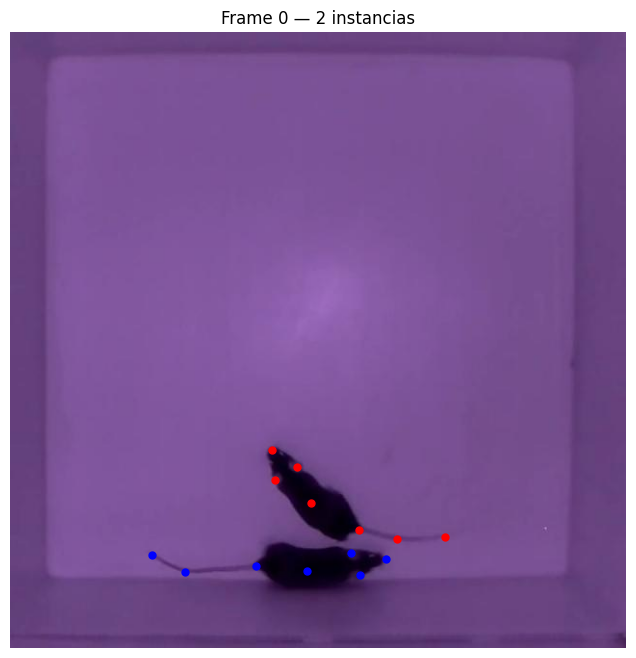

Si los puntos estan sobre los ratones, continuar. Si no, revisar la conversion.


In [16]:
# Celda 6 — Verificar keypoints visualmente
import matplotlib.pyplot as plt
import numpy as np

lf = labels[0]
frame = lf.image
h, w = frame.shape[:2]

plt.figure(figsize=(8,8))
plt.imshow(frame)
colors = ['ro', 'bo']
for i, inst in enumerate(lf.instances):
    pts = inst.numpy()
    for pt in pts:
        if not np.isnan(pt[0]):
            plt.plot(pt[0], pt[1], colors[i % 2], markersize=5)
plt.title(f"Frame 0 — {len(lf.instances)} instancias")
plt.axis('off')
plt.show()
print("Si los puntos estan sobre los ratones, continuar. Si no, revisar la conversion.")

In [ ]:
# Celda 7 — Configurar y entrenar modelo
config_yaml = """
data_config:
  train_labels_path:
    - data/dataset_ratones.slp
  validation_fraction: 0.1
  augmentation_config:
    geometric:
      rotation_min: -180.0
      rotation_max: 180.0
      scale_min: 0.8
      scale_max: 1.2
      affine_p: 1.0

model_config:
  backbone_config:
    unet:
      kernel_size: 3
      filters: 64
      filters_rate: 2.0
      max_stride: 16
      middle_block: true
      up_interpolate: true
      stacks: 1
  head_configs:
    bottomup:
      confmaps:
        part_names:
          - tail_tip
          - tail_base
          - tail_start
          - mid_body
          - nose
          - right_ear
          - left_ear
        sigma: 2.0
        output_stride: 2
      pafs:
        sigma: 2.0
        output_stride: 2

trainer_config:
  max_epochs: 50
  save_ckpt: true
  ckpt_dir: models/
  run_name: bottomup_ratones
  train_data_loader:
    batch_size: 4
  val_data_loader:
    batch_size: 4
  optimizer_name: Adam
  optimizer:
    lr: 0.0001
"""

with open("config_bottomup.yaml", "w") as f:
    f.write(config_yaml)

print("Config guardada. Iniciando entrenamiento (~30-60 min)...")
!sleap-nn train config_bottomup.yaml

Config guardada. Iniciando entrenamiento (~30-60 min)...
2026-03-20 05:19:46 | Input config:
2026-03-20 05:19:46 | 
data_config:
  train_labels_path:
  - data/dataset_ratones.slp
  validation_fraction: 0.1
  augmentation_config:
    geometric:
      rotation_min: -180.0
      rotation_max: 180.0
      scale_min: 0.8
      scale_max: 1.2
      affine_p: 1.0
model_config:
  backbone_config:
    unet:
      kernel_size: 3
      filters: 64
      filters_rate: 2.0
      max_stride: 16
      middle_block: true
      up_interpolate: true
      stacks: 1
  head_configs:
    bottomup:
      confmaps:
        part_names:
        - tail_tip
        - tail_base
        - tail_start
        - mid_body
        - nose
        - right_ear
        - left_ear
        sigma: 2.0
        output_stride: 2
      pafs:
        sigma: 2.0
        output_stride: 2
trainer_config:
  max_epochs: 50
  save_ckpt: true
  ckpt_dir: models/
  run_name: bottomup_ratones
  train_data_loader:
    batch_size: 4
  val_da

In [ ]:
# Celda 8 — Verificar modelo entrenado
import os

model_path = "models/bottomup_ratones/"
if os.path.exists(model_path):
    print(f"Archivos del modelo: {os.listdir(model_path)}")
else:
    print("ERROR: modelo no encontrado")

In [ ]:
# Celda 9 — Probar inferencia con video de prueba
# Subir video desde tu laptop
from google.colab import files
uploaded = files.upload()  # selecciona tu video .mp4

# Obtener nombre del archivo subido
video_name = list(uploaded.keys())[0]
print(f"Video subido: {video_name}")

# Correr inferencia
!sleap-nn track -i {video_name} --model_paths models/bottomup_ratones --output_path predictions.slp
print("Inferencia completada. Resultados en predictions.slp")

In [ ]:
# Celda 10 — Visualizar predicciones
import sleap_io as sio
import matplotlib.pyplot as plt
import numpy as np

preds = sio.load_file("predictions.slp")
print(f"Frames predichos: {len(preds)}")

# Mostrar primer frame con predicciones
lf = preds[0]
frame = lf.image

plt.figure(figsize=(10,10))
plt.imshow(frame)
colors = ['ro', 'bo']
for i, inst in enumerate(lf.instances):
    pts = inst.numpy()
    for pt in pts:
        if not np.isnan(pt[0]):
            plt.plot(pt[0], pt[1], colors[i % 2], markersize=8)
plt.title(f"Predicciones frame 0 — {len(lf.instances)} instancias")
plt.axis('off')
plt.show()

In [ ]:
# Celda 11 — Descargar modelo entrenado
from google.colab import files
import shutil

shutil.make_archive("modelo_sleap_ratones", "zip", "models/")
files.download("modelo_sleap_ratones.zip")
print("Descargando modelo...")
print("Guardar en: C:/Users/Fernando/Desktop/RATAS/claude-rata/sleap/models/")

## Usar el modelo en tu laptop

1. Descomprime `modelo_sleap_ratones.zip` en `sleap/models/`
2. Activa el entorno: `conda activate sleap`
3. Corre inferencia:
```
sleap-nn track -i data/input/TU_VIDEO.mp4 --model_paths models/bottomup_ratones --output_path predicciones.slp
```
4. Los resultados quedan en `predicciones.slp`